First 5 Records:
+--------+--------+-----+
|duration|    page| user|
+--------+--------+-----+
|      42| contact|user3|
|      91|products|user5|
|      50| contact|user1|
|       5|    cart|user2|
|      68|    cart|user1|
+--------+--------+-----+
only showing top 5 rows
Page Visit Analysis:
+--------+-----+
|    page|count|
+--------+-----+
|    Home|   17|
| contact|   16|
|    cart|   22|
|checkout|   17|
|   about|   16|
|products|   12|
+--------+-----+

Average Time Spent on Each Page:
+--------+-----------------+
|    page|    avg(duration)|
+--------+-----------------+
|    Home|65.23529411764706|
| contact|            73.25|
|    cart|61.90909090909091|
|checkout|64.88235294117646|
|   about|          59.3125|
|products|             69.0|
+--------+-----------------+



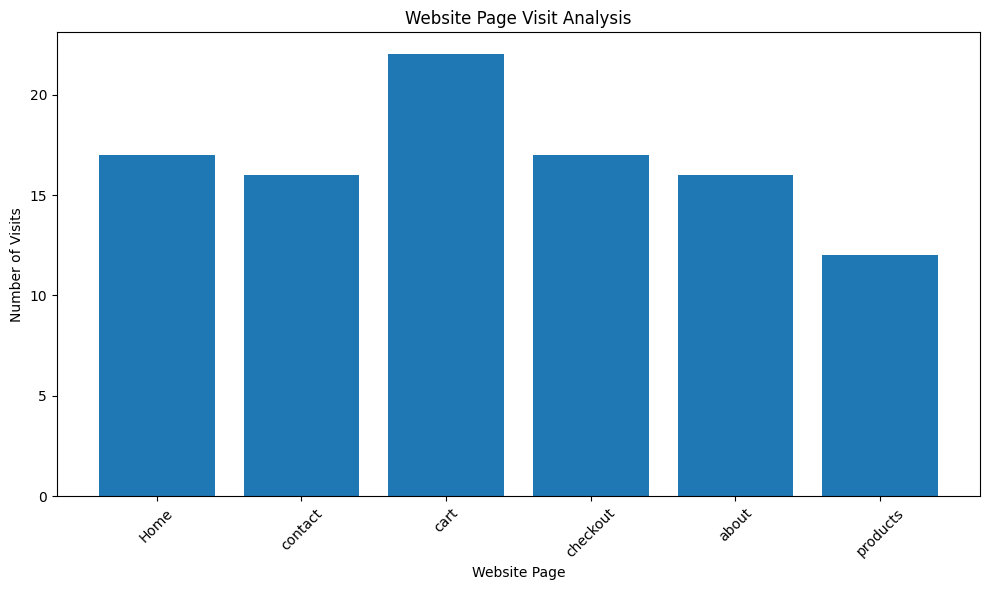

Report saved successfully.


In [5]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt

# Create Spark Session
spark = SparkSession.builder \
    .appName("Website Clickstream Analysis") \
    .getOrCreate()

# Create PySpark DataFrame
spark_df = spark.createDataFrame(data)

# Display first 5 records
print("First 5 Records:")
spark_df.show(5)

# Count visits for each page
pg = spark_df.groupBy("page").count()

print("Page Visit Analysis:")
pg.show()

# Calculate average duration for each page
avg_t = spark_df.groupBy("page").avg("duration")

print("Average Time Spent on Each Page:")
avg_t.show()

# Convert PySpark DataFrame to Pandas
pg_visits = pg.toPandas()

# Create bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    pg_visits["page"],
    pg_visits["count"]
)

plt.xlabel("Website Page")
plt.ylabel("Number of Visits")
plt.title("Website Page Visit Analysis")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Save analysis report
pg_visits.to_csv(
    "website_click_analysis_report.csv",
    index=False
)

print("Report saved successfully.")

# Stop Spark Session
spark.stop()
